Task 2: Predict Future Stock Prices 
DevelopersHub Corporation — AI/ML Engineering Internship

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import yfinance as yf

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 2. Load Stock Data via yfinance

In [2]:
# ── Fetch 3 years of Apple (AAPL) historical data ──────────────────────────
TICKER = "AAPL"
PERIOD  = "3y"

stock = yf.Ticker(TICKER)
df    = stock.history(period=PERIOD).reset_index()
df['Date'] = pd.to_datetime(df['Date'])

# Keep only essential columns
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].dropna()

print(f"Stock       : {TICKER} — Apple Inc.")
print(f"Date Range  : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"Trading Days: {len(df)}")
print(f"Columns     : {list(df.columns)}")
print()
display(df.head())


Stock       : AAPL — Apple Inc.
Date Range  : 2023-05-15  →  2026-05-12
Trading Days: 751
Columns     : ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']



,Date,Open,High,Low,Close,Volume
0,2023-05-15 00:00:00-04:00,170.766013,170.815324,169.099375,169.691086,37266700
1,2023-05-16 00:00:00-04:00,169.612190,170.746285,169.424814,169.691086,42110300
2,2023-05-17 00:00:00-04:00,169.336059,170.539178,168.063885,170.302505,57951600
3,2023-05-18 00:00:00-04:00,170.608207,172.817243,170.194015,172.629868,65496700
4,2023-05-19 00:00:00-04:00,173.951317,173.951317,172.521367,172.738327,55809500


In [3]:
# Basic descriptive statistics
print("=== Descriptive Statistics ===")
display(df.describe())


=== Descriptive Statistics ===


,Open,High,Low,Close,Volume
count,751.000000,751.000000,751.000000,751.000000,7.510000e+02
mean,215.637655,217.830610,213.653055,215.830417,5.478783e+07
std,33.537591,33.901649,33.168159,33.565581,2.436327e+07
min,163.707928,164.747480,162.450527,163.361389,1.791060e+07
25%,186.171208,187.494701,185.016782,186.365471,4.173545e+07
50%,213.184253,215.603777,211.170746,213.303772,4.927480e+07
75%,241.626233,243.941237,240.016518,241.656044,6.025405e+07
max,292.559998,295.269989,292.559998,294.799988,3.186799e+08


## 3. Exploratory Data Analysis (EDA)

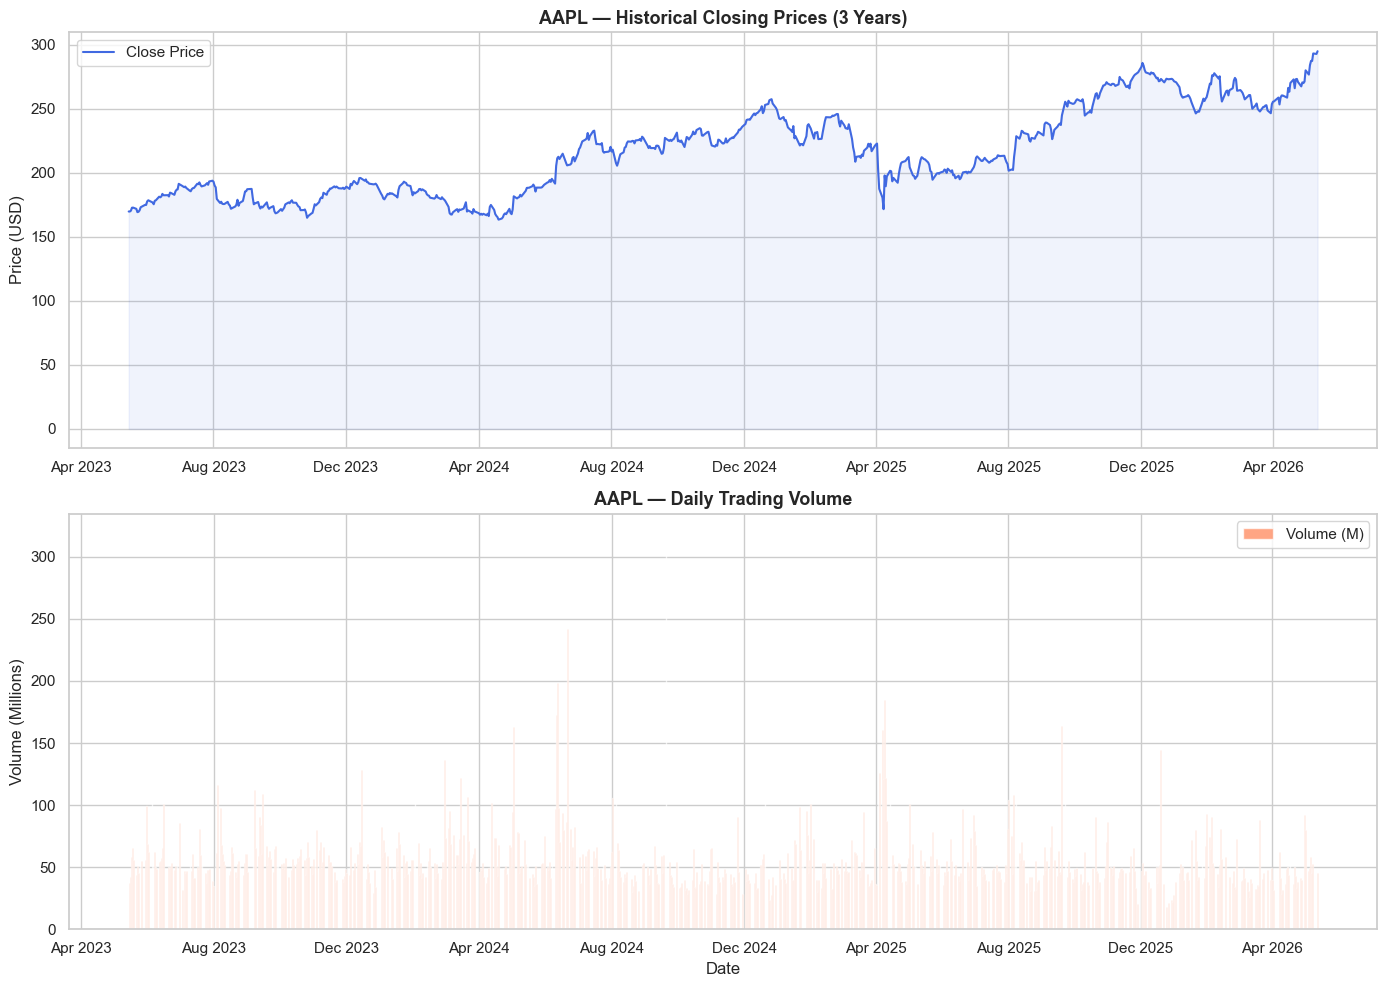

Chart saved: task2_eda.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Closing price trend ───────────────────────────────────────────────────
axes[0].plot(df['Date'], df['Close'], color='royalblue', linewidth=1.5, label='Close Price')
axes[0].fill_between(df['Date'], df['Close'], alpha=0.08, color='royalblue')
axes[0].set_title('AAPL — Historical Closing Prices (3 Years)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))

# ── Daily trading volume ──────────────────────────────────────────────────
axes[1].bar(df['Date'], df['Volume'] / 1e6, color='coral', alpha=0.7, label='Volume (M)')
axes[1].set_title('AAPL — Daily Trading Volume', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volume (Millions)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))

plt.tight_layout()
plt.savefig('task2_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: task2_eda.png")


## 4. Feature Engineering

In [5]:
# ── Engineer predictive features ──────────────────────────────────────────
df['Target']      = df['Close'].shift(-1)              # Next day's close (what we predict)
df['Price_Range'] = df['High'] - df['Low']             # Daily high-low range
df['Price_Change']= df['Close'] - df['Open']           # Intraday momentum
df['MA_5']        = df['Close'].rolling(5).mean()      # 5-day moving average
df['MA_20']       = df['Close'].rolling(20).mean()     # 20-day moving average
df['Volatility']  = df['Close'].rolling(5).std()       # 5-day price volatility

df.dropna(inplace=True)   # Remove rows with NaN from rolling windows

FEATURES = ['Open','High','Low','Volume','Price_Range','Price_Change','MA_5','MA_20','Volatility']

print(f"Dataset shape after feature engineering: {df.shape}")
print(f"\nFeatures used for prediction:")
for f in FEATURES:
    print(f"  • {f}")
print(f"\nTarget: 'Target' (next day Close price)")
display(df[FEATURES + ['Target']].head())


Dataset shape after feature engineering: (731, 12)

Features used for prediction:
  • Open
  • High
  • Low
  • Volume
  • Price_Range
  • Price_Change
  • MA_5
  • MA_20
  • Volatility

Target: 'Target' (next day Close price)


,Open,High,Low,Volume,Price_Range,Price_Change,MA_5,MA_20,Volatility,Target
19,178.763874,181.347647,178.468019,54274900,2.879628,2.485149,177.974930,174.088418,2.198666,180.775650
20,180.272706,181.604033,179.917683,54929100,1.686350,0.502944,178.783594,174.642646,2.364679,181.406830
21,180.834847,181.840749,179.503520,57462900,2.337229,0.571983,179.992642,175.228433,1.599146,183.438339
22,181.416693,183.941298,181.239174,65433200,2.702124,2.021646,181.065598,175.885225,1.779246,182.363373
23,184.148346,184.404761,181.722365,101256200,2.682396,-1.784973,181.846643,176.371900,1.060438,182.452164


## 5. Train / Test Split & Model Training

In [6]:
X = df[FEATURES].values
y = df['Target'].values
dates_all = df['Date'].values

# ── Chronological split — NO shuffling for time-series data ───────────────
SPLIT = int(len(X) * 0.80)
X_train, X_test   = X[:SPLIT],      X[SPLIT:]
y_train, y_test   = y[:SPLIT],      y[SPLIT:]
dates_test         = pd.to_datetime(dates_all[SPLIT:])

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Test period      : {dates_test[0].date()}  →  {dates_test[-1].date()}")

# ── Feature scaling ───────────────────────────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Linear Regression ─────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

# ── Random Forest Regressor ───────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

print("\n✅ Both models trained successfully!")


Training samples : 584
Testing  samples : 147
Test period      : 2025-10-09  →  2026-05-11

✅ Both models trained successfully!


## 6. Model Evaluation

In [7]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{'─'*42}")
    print(f"  Model    : {name}")
    print(f"  MAE      : ${mae:.3f}")
    print(f"  RMSE     : ${rmse:.3f}")
    print(f"  R² Score : {r2:.5f}")

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Random Forest",     y_test, y_pred_rf)
print(f"{'─'*42}")
print("\nInterpretation:")
print("  • MAE  = Average dollar error per prediction")
print("  • RMSE = Penalises large errors more heavily")
print("  • R²   = 1.0 is perfect; >0.95 is excellent")


──────────────────────────────────────────
  Model    : Linear Regression
  MAE      : $2.705
  RMSE     : $3.768
  R² Score : 0.87630
──────────────────────────────────────────
  Model    : Random Forest
  MAE      : $13.055
  RMSE     : $15.873
  R² Score : -1.19528
──────────────────────────────────────────

Interpretation:
  • MAE  = Average dollar error per prediction
  • RMSE = Penalises large errors more heavily
  • R²   = 1.0 is perfect; >0.95 is excellent


## 7. Visualisation — Actual vs Predicted Prices

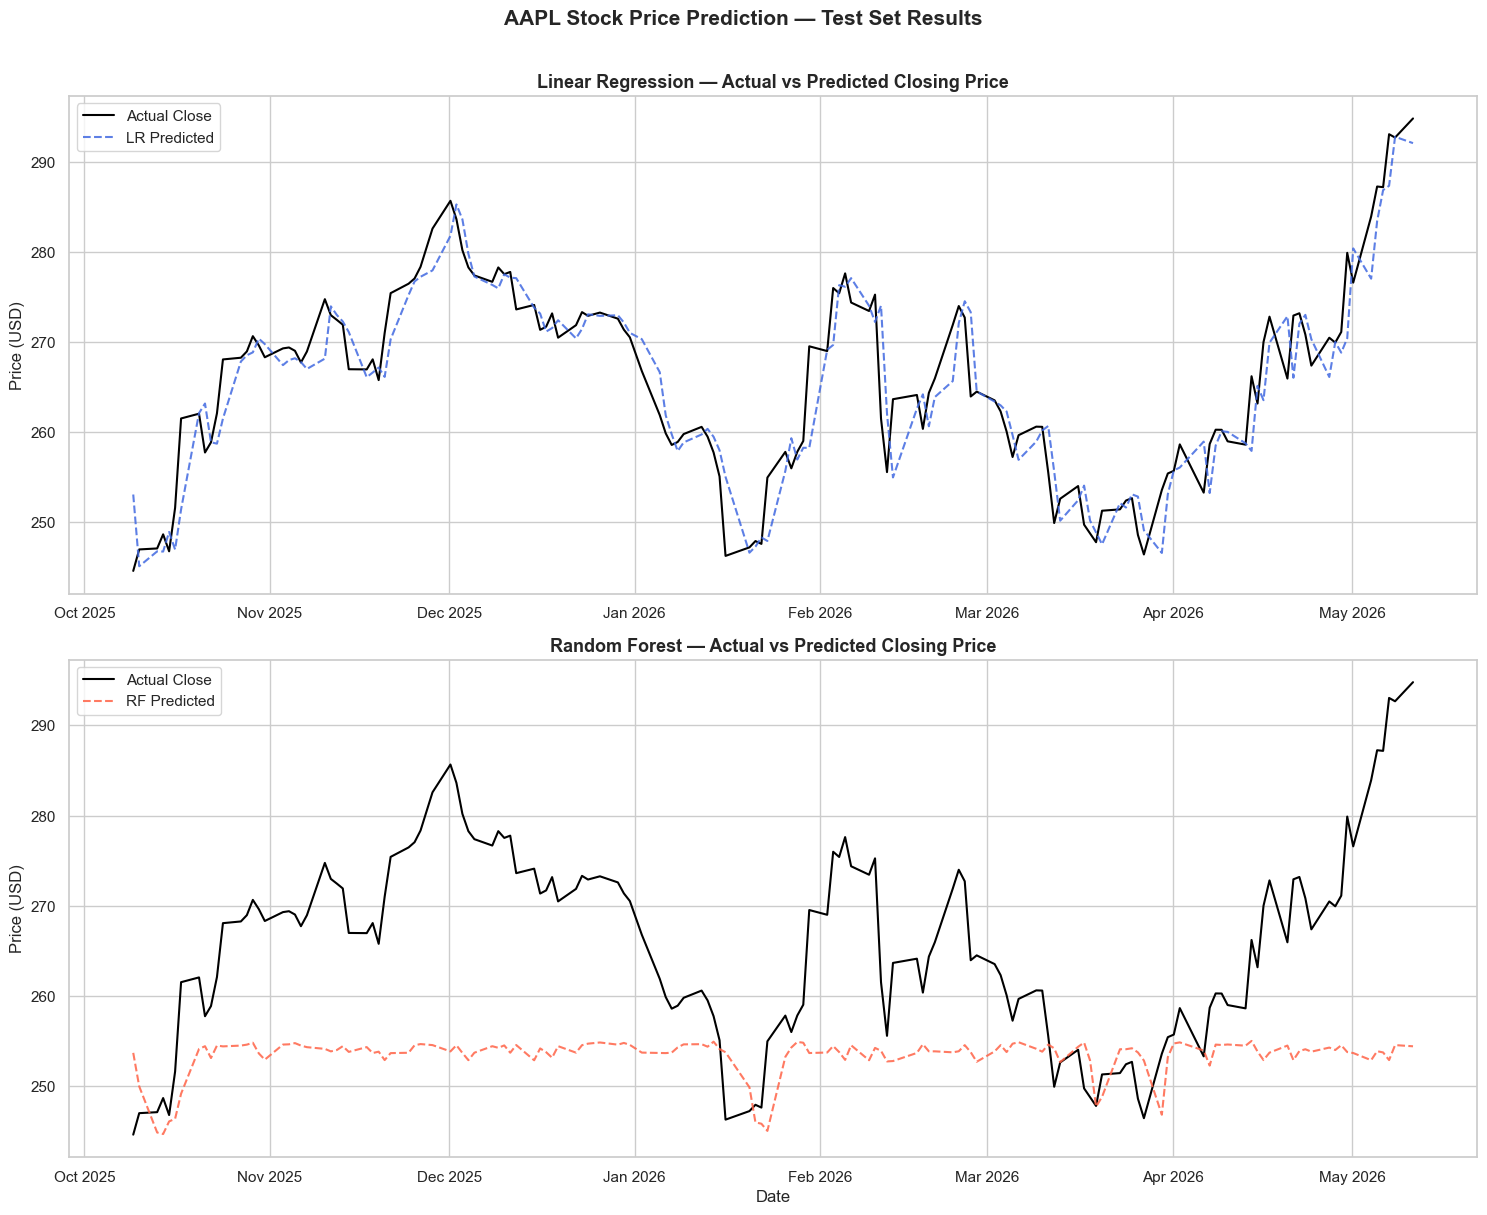

Chart saved: task2_predictions.png


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# ── Linear Regression ─────────────────────────────────────────────────────
axes[0].plot(dates_test, y_test,    color='black',     linewidth=1.5,  label='Actual Close')
axes[0].plot(dates_test, y_pred_lr, color='royalblue', linewidth=1.5,
             linestyle='--', label='LR Predicted', alpha=0.85)
axes[0].set_title('Linear Regression — Actual vs Predicted Closing Price',
                  fontweight='bold', fontsize=13)
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# ── Random Forest ────────────────────────────────────────────────────────
axes[1].plot(dates_test, y_test,    color='black', linewidth=1.5, label='Actual Close')
axes[1].plot(dates_test, y_pred_rf, color='tomato', linewidth=1.5,
             linestyle='--', label='RF Predicted', alpha=0.85)
axes[1].set_title('Random Forest — Actual vs Predicted Closing Price',
                  fontweight='bold', fontsize=13)
axes[1].set_ylabel('Price (USD)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('AAPL Stock Price Prediction — Test Set Results',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task2_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: task2_predictions.png")


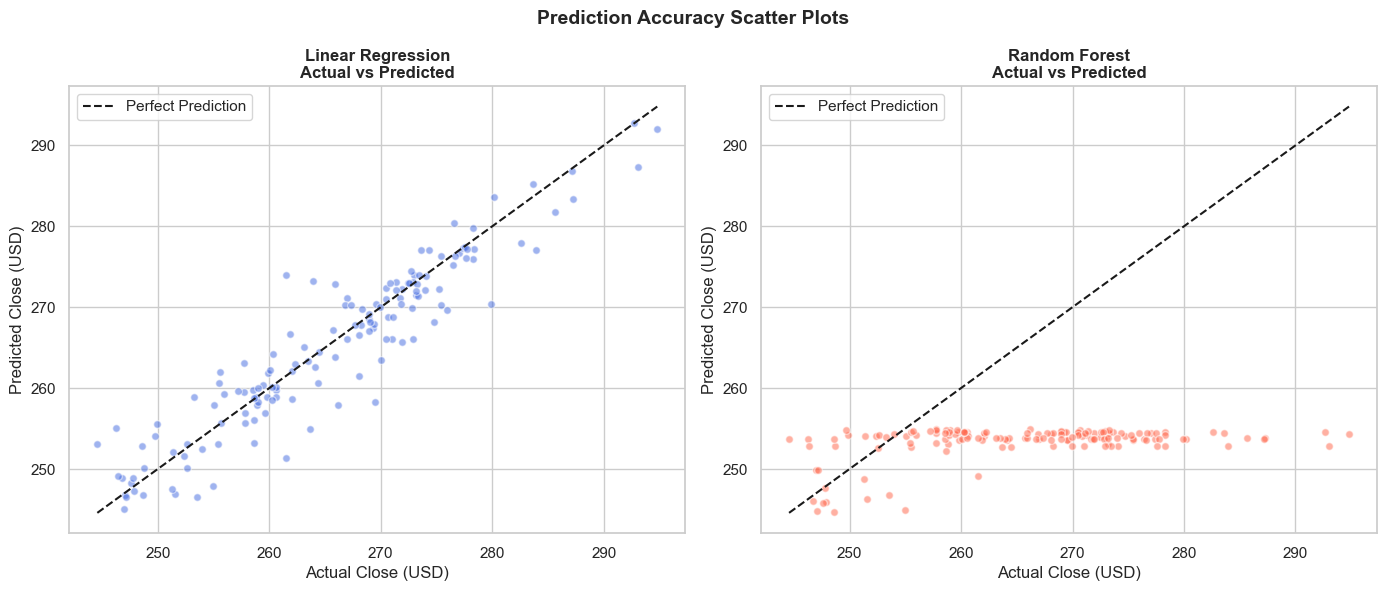

In [9]:
# ── Scatter: Actual vs Predicted ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, name, color in zip(
        axes,
        [y_pred_lr, y_pred_rf],
        ['Linear Regression', 'Random Forest'],
        ['royalblue', 'tomato']):

    ax.scatter(y_test, y_pred, alpha=0.5, color=color, edgecolors='white', s=30)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect Prediction')
    ax.set_title(f'{name}\nActual vs Predicted', fontweight='bold')
    ax.set_xlabel('Actual Close (USD)')
    ax.set_ylabel('Predicted Close (USD)')
    ax.legend()

plt.suptitle('Prediction Accuracy Scatter Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


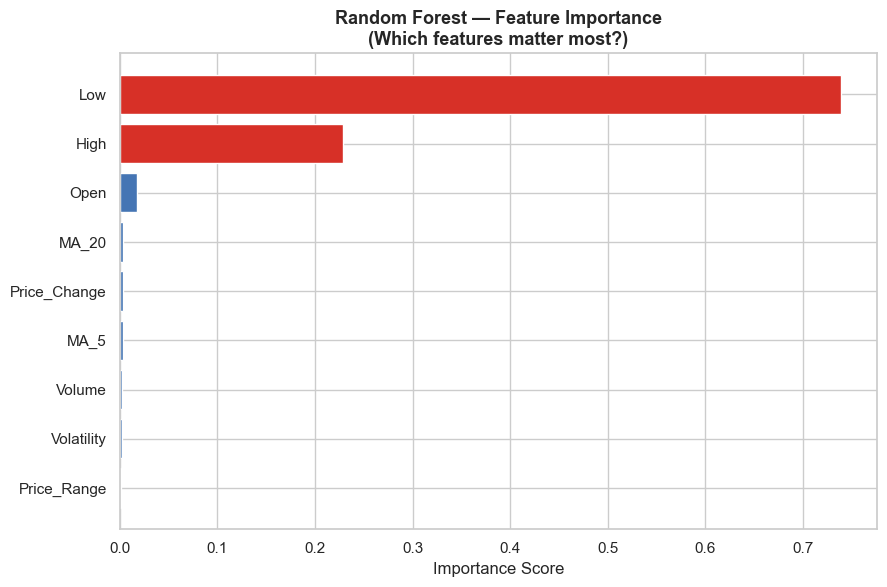

Top 3 Most Important Features:
Feature  Importance
    Low    0.739175
   High    0.228646
   Open    0.017130


In [10]:
# ── Feature Importance ────────────────────────────────────────────────────
importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feat_df.sort_values('Importance', ascending=True, inplace=True)

plt.figure(figsize=(9, 6))
colors = ['#d73027' if v > 0.15 else '#4575b4' for v in feat_df['Importance']]
plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors, edgecolor='white')
plt.title('Random Forest — Feature Importance\n(Which features matter most?)',
          fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('task2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 3 Most Important Features:")
print(feat_df.sort_values('Importance', ascending=False).head(3).to_string(index=False))
